# Exercise B.2 — Memetic Algorithms for TSP

This notebook compares a **simple EA** and a **memetic algorithm (MA)** for the Travelling Salesman Problem.

The MA extends the EA with **2-opt local search** applied to each offspring.

**EA configuration:**
- Permutation representation
- Tournament selection (K=5)
- Order crossover (OX) with p_c = 0.8
- Swap mutation with probability mu = 0.3
- Population size N = 100
- Generational replacement, no elitism

**Datasets:**
1. `file-tsp.txt` — 50 cities (custom instance)
2. TSPLIB benchmark instance (download a `.tsp` file and place it in this directory)

**Code structure:**
- `tsp_ea.py` — Core EA/MA (selection, crossover, mutation, 2-opt, runners)
- `experiments_b2.py` — Experiment runners for generation-based and time-based comparisons
- `plotting_b2.py` — Visualization functions

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from tsp_ea import (
    load_tsp_coordinates,
    load_tsplib,
    compute_distance_matrix,
    tour_distance,
    run_ea,
    run_ma,
)
from experiments_b2 import (
    load_dataset,
    experiment_generations,
    experiment_timed,
)
from plotting_b2 import (
    plot_convergence_generations,
    plot_convergence_timed,
    plot_final_distances,
    plot_tour,
    plot_time_comparison,
    plot_combined_convergence_gen,
    plot_combined_convergence_timed,
    plot_combined_final_distances,
    plot_combined_time_comparison,
    summary_table,
)

N_RUNS = 10
N_POP = 100
G_MAX = 200
K = 5
P_C = 0.8
MU = 0.3

## Load datasets

In [2]:
# Dataset 1: custom 50-city instance
coords_custom, dist_custom = load_dataset("file-tsp", "file-tsp.txt")
print(f"Custom dataset: {len(coords_custom)} cities")

# Dataset 2: TSPLIB instance
# Download a .tsp file from http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/
# e.g., eil51.tsp, berlin52.tsp, or att48.tsp
TSPLIB_FILE = "eil51.tsp"  # <-- change this to your downloaded file
coords_tsplib, dist_tsplib = load_dataset("tsplib", TSPLIB_FILE)
print(f"TSPLIB dataset: {len(coords_tsplib)} cities")

Custom dataset: 50 cities
TSPLIB dataset: 51 cities


## B.2.1 — Generation-based comparison (same generations, unfair)

First, we compare EA and MA using the **same number of generations**.
This is intentionally unfair: the MA performs additional 2-opt local search
each generation, consuming significantly more wall-clock time per generation.

### Dataset 1: custom 50-city instance

In [3]:
results_gen_custom = experiment_generations(
    dist_custom, n_runs=N_RUNS, N=N_POP, G_max=G_MAX, K=K, p_c=P_C, mu=MU
)

  Running simple EA (10 runs, 15 workers)...
    Run 1/10: best = 174.00, time = 0.5s
    Run 2/10: best = 152.76, time = 0.5s
    Run 3/10: best = 173.37, time = 0.5s
    Run 4/10: best = 156.31, time = 0.5s
    Run 5/10: best = 153.45, time = 0.6s
    Run 6/10: best = 152.82, time = 0.5s
    Run 7/10: best = 155.90, time = 0.6s
    Run 8/10: best = 160.33, time = 0.4s
    Run 9/10: best = 182.81, time = 0.4s
    Run 10/10: best = 150.76, time = 0.6s
  Running memetic algorithm (10 runs, 15 workers)...
    Run 1/10: best = 119.94, time = 23.1s
    Run 2/10: best = 119.94, time = 23.1s
    Run 3/10: best = 119.94, time = 33.0s
    Run 4/10: best = 119.94, time = 24.1s
    Run 5/10: best = 119.94, time = 26.8s
    Run 6/10: best = 119.94, time = 28.7s
    Run 7/10: best = 119.94, time = 23.4s
    Run 8/10: best = 119.94, time = 32.9s
    Run 9/10: best = 119.94, time = 32.9s
    Run 10/10: best = 119.94, time = 23.7s


In [4]:
summary_table(results_gen_custom, "Custom 50-city (generation-based)")


  Custom 50-city (generation-based)
  Simple EA:
    Best distance: 150.76
    Mean distance: 161.25 +/- 10.69
    Mean time:     0.5s
  MA (EA + 2-opt):
    Best distance: 119.94
    Mean distance: 119.94 +/- 0.00
    Mean time:     27.2s



### Dataset 2: TSPLIB instance

In [5]:
results_gen_tsplib = experiment_generations(
    dist_tsplib, n_runs=N_RUNS, N=N_POP, G_max=G_MAX, K=K, p_c=P_C, mu=MU
)

  Running simple EA (10 runs, 15 workers)...
    Run 1/10: best = 566.07, time = 0.4s
    Run 2/10: best = 549.47, time = 0.4s
    Run 3/10: best = 595.56, time = 0.4s
    Run 4/10: best = 619.02, time = 0.4s
    Run 5/10: best = 583.49, time = 0.5s
    Run 6/10: best = 554.12, time = 0.4s
    Run 7/10: best = 533.80, time = 0.4s
    Run 8/10: best = 533.87, time = 0.5s
    Run 9/10: best = 613.83, time = 0.5s
    Run 10/10: best = 519.13, time = 0.5s
  Running memetic algorithm (10 runs, 15 workers)...
    Run 1/10: best = 428.98, time = 32.4s
    Run 2/10: best = 428.98, time = 24.2s
    Run 3/10: best = 429.53, time = 22.5s
    Run 4/10: best = 428.87, time = 23.7s
    Run 5/10: best = 428.98, time = 24.3s
    Run 6/10: best = 428.87, time = 32.2s
    Run 7/10: best = 428.87, time = 31.2s
    Run 8/10: best = 428.87, time = 23.5s
    Run 9/10: best = 429.53, time = 32.9s
    Run 10/10: best = 428.87, time = 24.3s


In [6]:
summary_table(results_gen_tsplib, "TSPLIB (generation-based)")


  TSPLIB (generation-based)
  Simple EA:
    Best distance: 519.13
    Mean distance: 566.84 +/- 33.09
    Mean time:     0.4s
  MA (EA + 2-opt):
    Best distance: 428.87
    Mean distance: 429.04 +/- 0.25
    Mean time:     27.1s



### Combined generation-based results

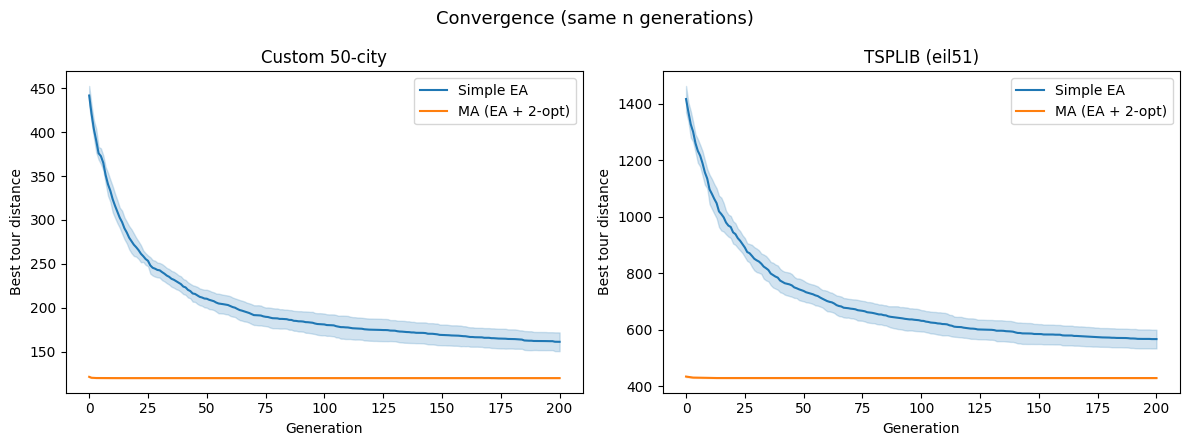

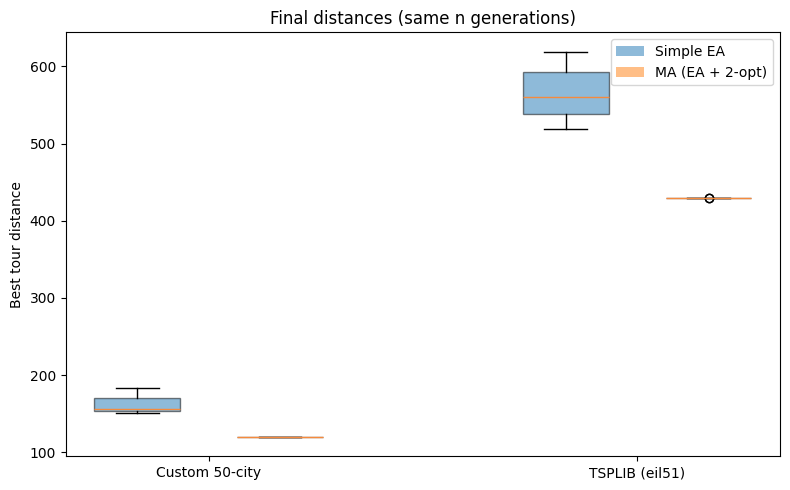

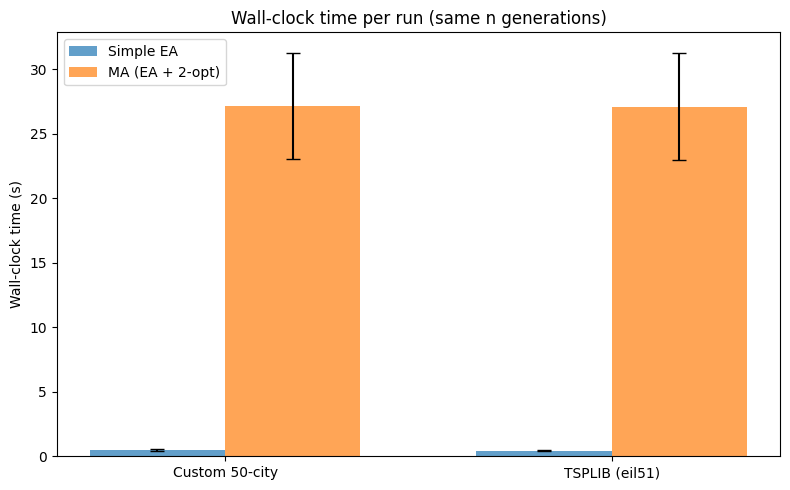

In [7]:
fig = plot_combined_convergence_gen(results_gen_custom, results_gen_tsplib,
    title="Convergence (same n generations)")
plt.show()

fig = plot_combined_final_distances(results_gen_custom, results_gen_tsplib,
    title="Final distances (same n generations)")
plt.show()

fig = plot_combined_time_comparison(results_gen_custom, results_gen_tsplib,
    title="Wall-clock time per run (same n generations)")
plt.show()

## B.2.1 Discussion — Is same-generation comparison fair?

Comparing EA and MA with the same number of generations is **not a fair comparison**.

The MA performs 2-opt local search on every offspring, which is computationally
expensive. Even though both algorithms run the same number of generations, the MA
uses orders of magnitude more wall-clock time (as shown in the bar chart above).

A fairer comparison gives both algorithms the same **wall-clock time budget**, so
the EA can run many more generations to compensate for not having local search.
This equalizes the total computational resources available to each algorithm.

## B.2.2 — Time-based comparison (fair)

We give both algorithms the same wall-clock time budget.
The budget is set to the mean time the MA used in the generation-based experiment,
so the MA runs roughly the same number of generations as before, while the EA
gets many more generations to compensate.

In [8]:
# Use the MA's wall-clock time from generation-based runs as the budget
time_budget_custom = np.mean([r["elapsed"] for r in results_gen_custom["ma"]])
time_budget_tsplib = np.mean([r["elapsed"] for r in results_gen_tsplib["ma"]])
print(f"Time budget for custom dataset: {time_budget_custom:.1f}s")
print(f"Time budget for TSPLIB dataset: {time_budget_tsplib:.1f}s")

Time budget for custom dataset: 27.2s
Time budget for TSPLIB dataset: 27.1s


### Dataset 1: custom 50-city instance

In [9]:
results_timed_custom = experiment_timed(
    dist_custom, n_runs=N_RUNS, time_budget=time_budget_custom,
    N=N_POP, K=K, p_c=P_C, mu=MU
)

  Running simple EA (budget=27.2s, 10 runs, 15 workers)...
    Run 1/10: best = 153.77, gens = 10249
    Run 2/10: best = 136.89, gens = 13508
    Run 3/10: best = 154.05, gens = 11575
    Run 4/10: best = 138.10, gens = 11443
    Run 5/10: best = 148.22, gens = 10880
    Run 6/10: best = 140.40, gens = 13286
    Run 7/10: best = 155.32, gens = 9067
    Run 8/10: best = 159.02, gens = 13136
    Run 9/10: best = 151.03, gens = 11306
    Run 10/10: best = 141.65, gens = 10778
  Running MA (budget=27.2s, 10 runs, 15 workers)...
    Run 1/10: best = 119.94, gens = 135
    Run 2/10: best = 119.94, gens = 138
    Run 3/10: best = 119.94, gens = 218
    Run 4/10: best = 119.94, gens = 193
    Run 5/10: best = 119.94, gens = 226
    Run 6/10: best = 119.94, gens = 228
    Run 7/10: best = 119.94, gens = 190
    Run 8/10: best = 119.94, gens = 137
    Run 9/10: best = 119.94, gens = 223
    Run 10/10: best = 119.94, gens = 224


In [10]:
summary_table(results_timed_custom, "Custom 50-city (time-based)")


  Custom 50-city (time-based)
  Simple EA:
    Best distance: 136.89
    Mean distance: 147.84 +/- 7.57
    Mean gens:     11523
  MA (EA + 2-opt):
    Best distance: 119.94
    Mean distance: 119.94 +/- 0.00
    Mean gens:     191



### Dataset 2: TSPLIB instance

In [11]:
results_timed_tsplib = experiment_timed(
    dist_tsplib, n_runs=N_RUNS, time_budget=time_budget_tsplib,
    N=N_POP, K=K, p_c=P_C, mu=MU
)

  Running simple EA (budget=27.1s, 10 runs, 15 workers)...
    Run 1/10: best = 495.94, gens = 13734
    Run 2/10: best = 520.09, gens = 14483
    Run 3/10: best = 482.05, gens = 8217
    Run 4/10: best = 498.08, gens = 10049
    Run 5/10: best = 487.46, gens = 14324
    Run 6/10: best = 559.46, gens = 13058
    Run 7/10: best = 511.74, gens = 8220
    Run 8/10: best = 543.53, gens = 14579
    Run 9/10: best = 517.44, gens = 10158
    Run 10/10: best = 512.04, gens = 12447
  Running MA (budget=27.1s, 10 runs, 15 workers)...
    Run 1/10: best = 428.98, gens = 157
    Run 2/10: best = 428.98, gens = 188
    Run 3/10: best = 428.98, gens = 123
    Run 4/10: best = 428.98, gens = 134
    Run 5/10: best = 428.98, gens = 153
    Run 6/10: best = 428.98, gens = 195
    Run 7/10: best = 428.98, gens = 227
    Run 8/10: best = 428.87, gens = 232
    Run 9/10: best = 428.87, gens = 214
    Run 10/10: best = 428.87, gens = 227


In [12]:
summary_table(results_timed_tsplib, "TSPLIB (time-based)")


  TSPLIB (time-based)
  Simple EA:
    Best distance: 482.05
    Mean distance: 512.78 +/- 22.99
    Mean gens:     11927
  MA (EA + 2-opt):
    Best distance: 428.87
    Mean distance: 428.95 +/- 0.05
    Mean gens:     185



### Combined time-based results

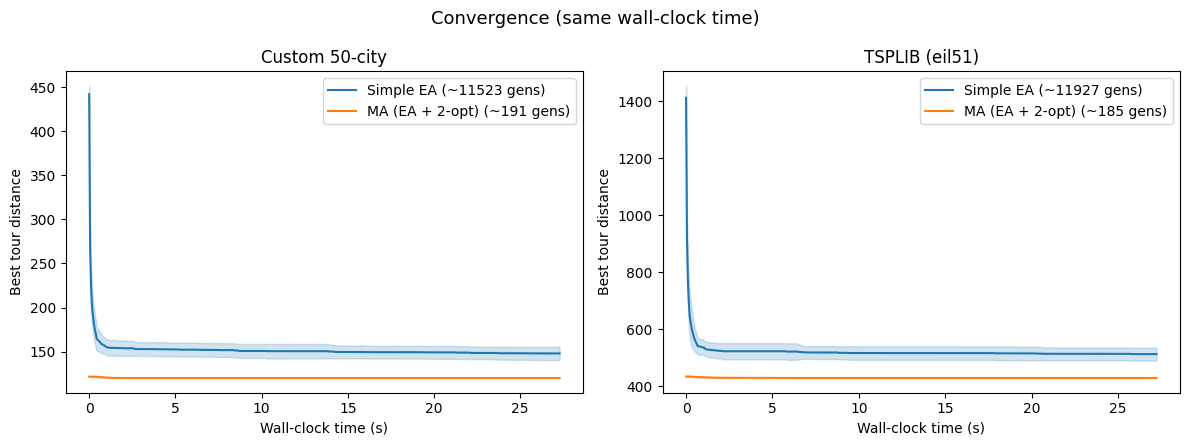

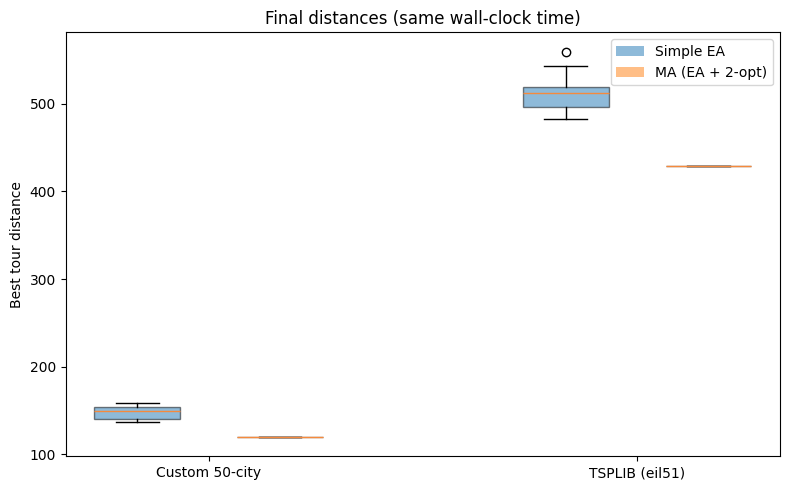

In [13]:
fig = plot_combined_convergence_timed(results_timed_custom, results_timed_tsplib,
    title="Convergence (same wall-clock time)")
plt.show()

fig = plot_combined_final_distances(results_timed_custom, results_timed_tsplib,
    title="Final distances (same wall-clock time)")
plt.show()

## Discussion

**Does the addition of local search improve performance?**

- In the **generation-based** (unfair) comparison, the MA clearly outperforms the simple EA, but it also uses far more computation time due to 2-opt.
- In the **time-based** (fair) comparison, both algorithms get the same wall-clock time. The EA can run many more generations, but the MA typically still produces better solutions because 2-opt efficiently exploits the local neighbourhood of each solution.
- The key insight is that local search and evolutionary search are complementary: the EA provides global exploration (crossover recombines diverse tours), while 2-opt provides local exploitation (removes crossing edges). Together they outperform either approach alone, even when given equal computational resources.